In [1]:
#Task 7
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
words = open('isimler_unique.txt', 'r').read().splitlines()

chars = sorted(list(set(''.join(words))))
stoi = {s:i+1 for i,s in enumerate(chars)}
stoi['.'] = 0
itos = {i:s for s,i in stoi.items()}
vocab_size = len(itos)

In [2]:
#dataset split
block_size = 3 # context length: how many characters do we take to predict the next one?

def build_dataset(words):  
  X, Y = [], []
  
  for w in words:
    context = [0] * block_size
    for ch in w + '.':
      ix = stoi[ch]
      X.append(context)
      Y.append(ix)
      context = context[1:] + [ix] # crop and append

  X = torch.tensor(X)
  Y = torch.tensor(Y)
  print(X.shape, Y.shape)
  return X, Y

import random
random.seed(42)
random.shuffle(words)
n1 = int(0.8*len(words))
n2 = int(0.9*len(words))

Xtr,  Ytr  = build_dataset(words[:n1])     # 80%
Xdev, Ydev = build_dataset(words[n1:n2])   # 10%
Xte,  Yte  = build_dataset(words[n2:])     # 10%

torch.Size([55346, 3]) torch.Size([55346])
torch.Size([6951, 3]) torch.Size([6951])
torch.Size([6937, 3]) torch.Size([6937])


In [3]:
n_embd = 10 # embeddings dimension
n_hidden = 200 # hidden layers's neuron amount

g = torch.Generator().manual_seed(2147483647) # for reproducibility
C  = torch.randn((vocab_size, n_embd),            generator=g)
W1 = torch.randn((n_embd * block_size, n_hidden), generator=g) * (5/3)/((n_embd * block_size)**0.5)
#b1 = torch.randn(n_hidden,                        generator=g) * 0.01
W2 = torch.randn((n_hidden, vocab_size),          generator=g) * 0.01
b2 = torch.randn(vocab_size,                      generator=g) * 0

bngain = torch.ones((1,n_hidden))
bnbias = torch.zeros((1,n_hidden))
bnmean_running = torch.zeros((1, n_hidden))
bnstd_running = torch.ones((1, n_hidden))


parameters = [C, W1,  W2, b2, bngain, bnbias]
print(sum(p.nelement() for p in parameters)) # number of parameters in total
for p in parameters:
  p.requires_grad = True


12730


In [4]:
#optimization block
max_steps = 200000
batch_size = 32
lossi = []

for i in range(max_steps):
  
  # minibatch construct
  ix = torch.randint(0, Xtr.shape[0], (batch_size,), generator=g)
  Xb, Yb = Xtr[ix], Ytr[ix] # batch X,Y
  
  # forward pass
  emb = C[Xb] # embed the characters into vectors
  embcat = emb.view(emb.shape[0], -1) # concatenate the vectors
  hpreact = embcat @ W1 #b1 # hidden layer pre-activation
  bnmeani = hpreact.mean(0, keepdim=True)
  bnstdi  = hpreact.std(0, keepdim=True)
  hpreact = bngain * (hpreact - bnmeani ) / (bnstdi) +bnbias #batch norming  
    
  with torch.no_grad():
    bnmean_running = 0.999 * bnmean_running + 0.001 * bnmeani
    bnstd_running = 0.999 * bnstd_running + 0.001 * bnstdi 
      
  h = torch.tanh(hpreact) # hidden layer
  logits = h @ W2 + b2 # output layer
  loss = F.cross_entropy(logits, Yb) # loss function
  
  # backward pass
  for p in parameters:
    p.grad = None
  loss.backward()
  
  # update
  lr = 0.1 if i < 100000 else 0.01 # step learning rate decay
  for p in parameters:
    p.data += -lr * p.grad

  # track stats
  if i % 10000 == 0: # print every once in a while
    print(f'{i:7d}/{max_steps:7d}: {loss.item():.4f}')
  lossi.append(loss.log10().item())

      0/ 200000: 3.3842
  10000/ 200000: 1.7972
  20000/ 200000: 1.8280
  30000/ 200000: 2.3115
  40000/ 200000: 2.2063
  50000/ 200000: 2.2970
  60000/ 200000: 2.0990
  70000/ 200000: 2.2693
  80000/ 200000: 2.0898
  90000/ 200000: 2.2867
 100000/ 200000: 2.5191
 110000/ 200000: 2.2337
 120000/ 200000: 1.9437
 130000/ 200000: 1.6239
 140000/ 200000: 1.9364
 150000/ 200000: 1.7593
 160000/ 200000: 1.8543
 170000/ 200000: 2.0627
 180000/ 200000: 1.7876
 190000/ 200000: 2.2087


In [5]:
#loss eval both in training and validation sets.
@torch.no_grad() # this decorator disables gradient tracking
def split_loss(split):
  x,y = {
    'train': (Xtr, Ytr),
    'val': (Xdev, Ydev),
    'test': (Xte, Yte),
  }[split]
  emb = C[x] # (N, block_size, n_embd)
  embcat = emb.view(emb.shape[0], -1) # concat into (N, block_size * n_embd)
  hpreact = embcat @ W1  #b1 # (N, n_hidden)  
  #hpreact = bngain * ((hpreact - hpreact.mean(0, keepdim=True)) / (hpreact.std(0, keepdim=True))) +bnbias #batch norming 
  hpreact = bngain * ((hpreact - bnmean_running) / (bnstd_running)) +bnbias #batch norming   
  h = torch.tanh(hpreact)
  logits = h @ W2 + b2 # (N, vocab_size)
  loss = F.cross_entropy(logits, y)
  print(split, loss.item())

split_loss('train')
split_loss('val')

train 1.881050944328308
val 2.076986074447632


In [6]:
#loss log

#turkish models loss 
#1.881050944328308
#2.076986074447632

#bn with running mean
# train 2.0674145221710205
# val 2.1056838035583496

#bn without running mean
#train 2.0668270587921143
#val 2.104844808578491

# kaiming init loss
# train 2.037754774093628
# val 2.1032512187957764

# after 2 fix losses 
# train 2.038102865219116
# val 2.101986885070801

# after fixing softmax
# train 2.069324493408203
# val 2.133208990097046

# original loss
# train 2.11914324760437
# val 2.162384510040283



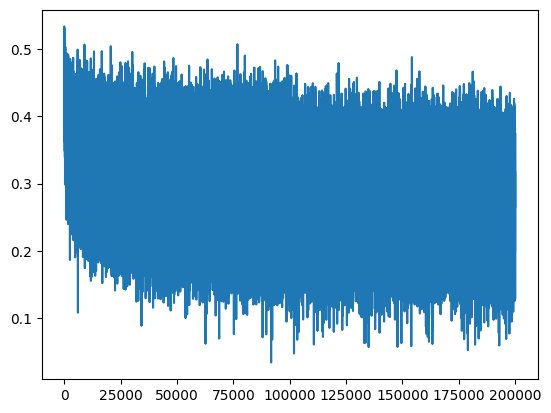

In [7]:
plt.plot(lossi)

In [8]:
for _ in range(20):
    
    out = []
    context = [0] * block_size # initialize with all ...
    while True:
      # forward pass the neural net
      emb = C[torch.tensor([context])] # (1,block_size,n_embd)
      embcat = emb.view(emb.shape[0], -1) # concatenate the vectors
      hpreact = embcat @ W1  #b1 # (N, n_hidden)  
      hpreact = bngain * ((hpreact - bnmean_running) / (bnstd_running)) +bnbias #batch norming   
      h = torch.tanh(hpreact)
      logits = h @ W2 + b2
      probs = F.softmax(logits, dim=1)
      # sample from the distribution
      ix = torch.multinomial(probs, num_samples=1, generator=g).item()
      # shift the context window and track the samples
      context = context[1:] + [ix]
      out.append(ix)
      # if we sample the special '.' token, break
      if ix == 0:
        break
    
    print(''.join(itos[i] for i in out)) # decode and print the generated word

hemdirzar.
say.
mauygun.
safagahbure.
ğahan.
merzık.
ilbeyduma.
mücar.
zecer.
akan.
vaibe.
yet.
allıkızgın.
sar.
nazat.
muklakim.
serik.
savet.
karahfet.
ülkutlu.


In [9]:
#biagram results we got much better output as expected
#güsu.
#oçmerslbi.
#te.
#ören.
#yhimur.